In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import os
from matplotlib import rcParams

%matplotlib inline

rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

# RUN184X 

##### (X=6 or 8)

In [11]:
import glob
import pandas as pd
import re

csv_folder = "/scratch/elena/9Li/results/run1846"
csv_files = sorted(glob.glob(f"{csv_folder}/Li9_clusters_chunk_*.csv"))


match = re.search(r'run(\d+)', csv_folder)
if match:
    run_number = match.group(1) 
    print(f"Run number: {run_number}")
else:
    run_number = "Not found!"

print(f"Found {len(csv_files)} chunk files")

df_list = []
for f in csv_files:
    try:
        df_chunk = pd.read_csv(f)
        if not df_chunk.empty:   # filter empty CSVs
            # Add new columns without dropping any existing ones
            df_chunk['t_window_start_s'] = df_chunk['t_window_start_ns'] / 1e9            # absolute time [s]
            df_chunk['t_window_start_rel_ms'] = df_chunk['t_window_start_rel_ns'] / 1e6   # relative time [ms]

            df_list.append(df_chunk)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {f}")

# concatenate all chunks
df = pd.concat(df_list, ignore_index=True)

print(f"Total clusters: {len(df)}")
display(df)

Run number: 1846
Found 50 chunk files
Total clusters: 15452


,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,nCLusters_in_spill,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,t_window_start_s,t_window_start_rel_ms
0,8.041410e+09,9.814304e+05,39,0,64,"[98, 98, 21, 93, 93, 93, 42, 99, 71, 71, 71, 9...","[100, 100, 64, 101, 101, 101, 80, 90, 103, 103...","[5, 3, 10, 3, 5, 4, 5, 17, 7, 9, 10, 8, 5, 16,...","[7, 18, 10, 18, 7, 1, 7, 15, 2, 3, 10, 9, 7, 1...","[8041410324.059747, 8041410326.036574, 8041410...","[67.0, 71.0, 54.0, 112.0, 96.0, 162.0, 128.0, ...",8.041410,0.981430
1,8.044887e+09,4.458099e+06,40,0,64,"[23, 23, 23, 23, 23, 36, 15, 15, 83, 83, 80, 8...","[47, 47, 47, 47, 47, 46, 58, 58, 28, 28, 30, 3...","[9, 11, 12, 13, 14, 14, 0, 5, 11, 18, 8, 9, 10...","[3, 11, 4, 12, 13, 13, 17, 7, 11, 16, 9, 3, 10...","[8044886990.237592, 8044886990.052327, 8044886...","[153.0, 2071.0, 142.0, 1419.0, 230.0, 204.0, 2...",8.044887,4.458099
2,8.048710e+09,8.281018e+06,37,0,64,"[25, 42, 20, 20, 20, 71, 71, 71, 8, 8, 8, 8, 2...","[62, 80, 81, 81, 81, 103, 103, 103, 84, 84, 84...","[12, 11, 7, 1, 6, 6, 10, 9, 3, 6, 9, 12, 5, 6,...","[4, 11, 2, 6, 8, 8, 10, 3, 18, 8, 3, 4, 7, 8, ...","[8048709914.746663, 8048709909.997618, 8048709...","[139.0, 160.0, 134.0, 113.0, 133.0, 114.0, 163...",8.048710,8.281018
3,8.053620e+09,1.319130e+07,37,0,64,"[34, 98, 32, 17, 15, 93, 93, 89, 97, 97, 97, 9...","[78, 100, 75, 29, 58, 101, 101, 89, 92, 92, 92...","[2, 14, 15, 2, 15, 15, 17, 17, 1, 2, 6, 9, 10,...","[0, 13, 5, 0, 5, 5, 15, 15, 6, 0, 8, 3, 10, 5,...","[8053620188.768547, 8053620190.825874, 8053620...","[145.0, 174.0, 84.0, 169.0, 154.0, 185.0, 89.0...",8.053620,13.191298
4,8.055017e+09,1.458829e+07,38,0,64,"[103, 35, 26, 83, 73, 47, 111, 99, 87, 11, 109...","[98, 76, 60, 28, 31, 13, 97, 90, 88, 10, 104, ...","[12, 4, 14, 13, 5, 7, 15, 1, 12, 3, 0, 8, 4, 7...","[4, 1, 13, 12, 7, 2, 5, 6, 4, 18, 17, 9, 1, 2,...","[8055017192.668688, 8055017198.512238, 8055017...","[181.0, 170.0, 197.0, 116.0, 120.0, 127.0, 164...",8.055017,14.588292
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15447,2.168110e+12,4.396397e+08,37,55,69,"[89, 89, 35, 32, 32, 32, 32, 93, 93, 26, 34, 3...","[89, 89, 76, 75, 75, 75, 75, 101, 101, 60, 78,...","[1, 17, 4, 1, 16, 2, 15, 16, 2, 4, 3, 18, 3, 1...","[6, 15, 1, 6, 14, 0, 5, 14, 0, 1, 18, 16, 18, ...","[2168109814041.78, 2168109814043.3596, 2168109...","[120.0, 158.0, 164.0, 120.0, 175.0, 154.0, 208...",2168.109814,439.639679
15448,2.168112e+12,4.413925e+08,36,55,69,"[16, 16, 34, 111, 15, 47, 107, 113, 113, 19, 1...","[73, 73, 78, 97, 58, 13, 44, 26, 26, 41, 10, 1...","[7, 9, 1, 2, 8, 10, 6, 8, 11, 9, 11, 15, 7, 10...","[2, 3, 6, 0, 9, 10, 8, 9, 11, 3, 11, 5, 2, 3, ...","[2168111566832.292, 2168111566832.5366, 216811...","[163.0, 187.0, 91.0, 87.0, 187.0, 177.0, 120.0...",2168.111567,441.392479
15449,2.168126e+12,4.562004e+08,42,55,69,"[25, 89, 36, 36, 36, 36, 36, 83, 44, 73, 113, ...","[62, 89, 46, 46, 46, 46, 46, 28, 43, 31, 26, 2...","[0, 12, 2, 3, 4, 9, 13, 16, 5, 8, 1, 3, 14, 16...","[17, 4, 0, 18, 1, 3, 12, 14, 7, 9, 6, 18, 13, ...","[2168126374780.7302, 2168126374782.7996, 21681...","[269.0, 91.0, 392.0, 957.0, 384.0, 264.0, 65.0...",2168.126375,456.200414
15450,2.168128e+12,4.575307e+08,43,55,69,"[35, 35, 25, 25, 26, 98, 107, 42, 42, 42, 42, ...","[76, 76, 62, 62, 60, 100, 44, 80, 80, 80, 80, ...","[7, 15, 1, 2, 13, 0, 11, 2, 4, 9, 12, 15, 1, 7...","[2, 5, 6, 0, 12, 17, 11, 0, 1, 3, 4, 5, 6, 2, ...","[2168127705065.426, 2168127705066.6394, 216812...","[183.0, 190.0, 52.0, 178.0, 191.0, 99.0, 177.0...",2168.127705,457.530702


In [12]:
activity_df = df.drop_duplicates(subset=['spill_id'])[['spill_id', 'nCLusters_in_spill']]
print(activity_df)

       spill_id  nCLusters_in_spill
0             0                  64
64            1                  46
110           2                  39
149           3                  47
196           4                  47
...         ...                 ...
15101        50                  62
15189        51                  48
15237        52                  51
15288        53                  56
15344        54                  39

[258 rows x 2 columns]


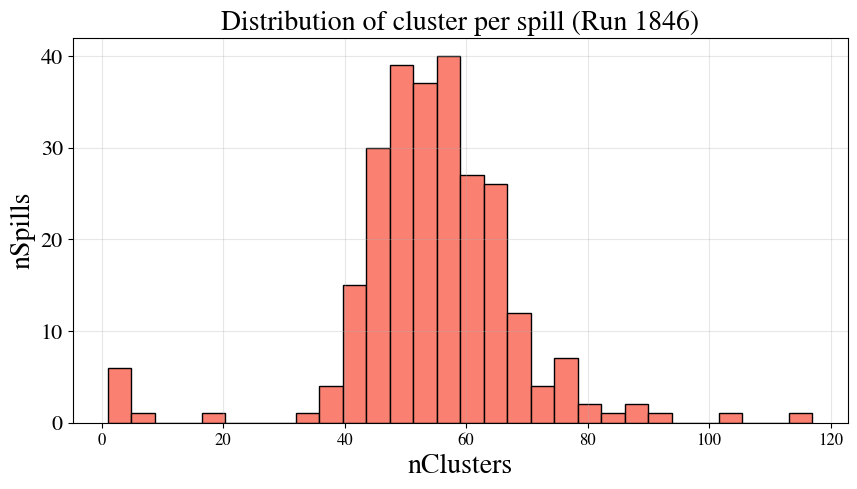

Total Clusters found in these spills: 14117
Average Clusters per 'Active' Spill: 54.72


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(activity_df['nCLusters_in_spill'], bins=30, color='salmon', edgecolor='black')
plt.title(f"Distribution of cluster per spill (Run {run_number})")
plt.xlabel("nClusters")
plt.ylabel("nSpills")
plt.grid(alpha=0.3)
plt.show()

print(f"Total Clusters found in these spills: {activity_df['nCLusters_in_spill'].sum()}")
print(f"Average Clusters per 'Active' Spill: {activity_df['nCLusters_in_spill'].mean():.2f}")

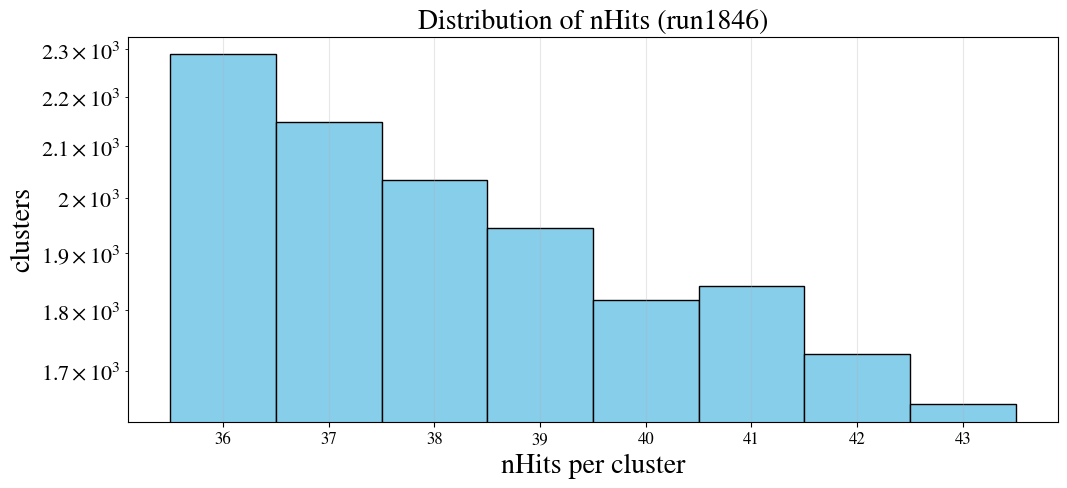

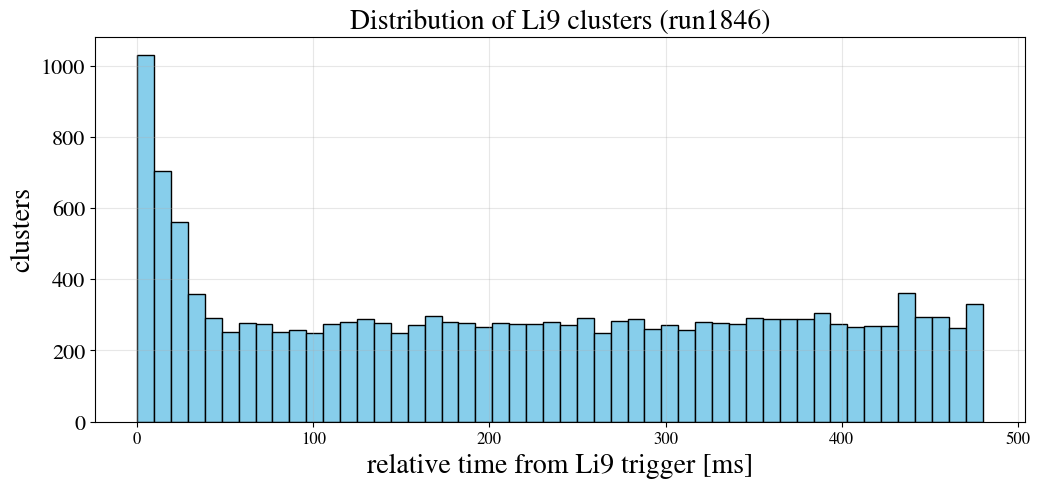

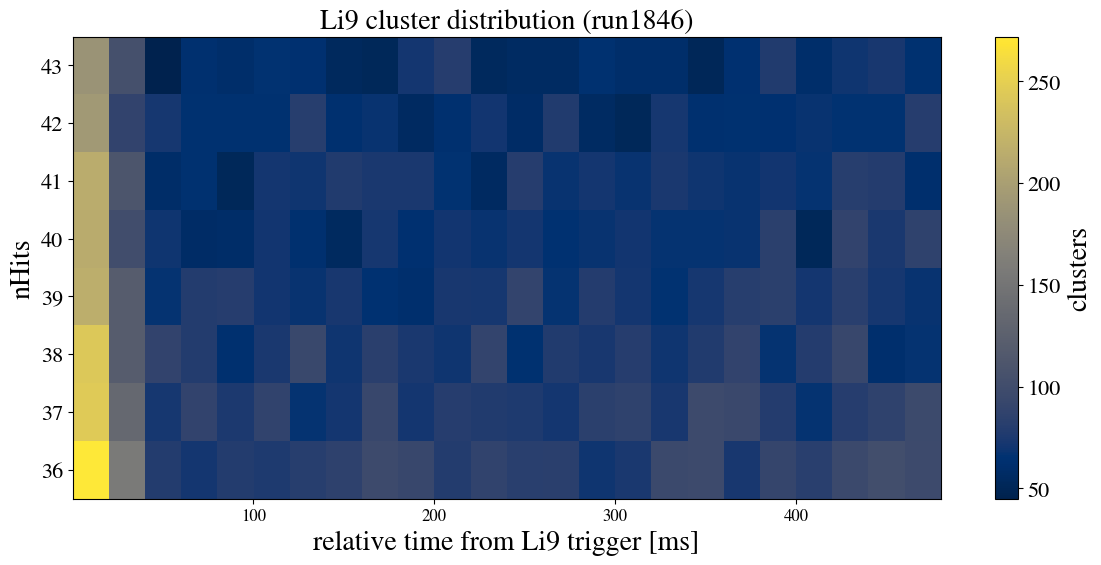

In [14]:
# -------------------------
# 2. 1D Histograms
# -------------------------

# Histogram: nHits per cluster
plt.figure(figsize=(12,5))
n_bins = np.arange(df['nHits'].min(), df['nHits'].max()+2) - 0.5            # +2 ensures the top-most value lands in a bin, the -0.5 centers bins on integers.
plt.hist(df['nHits'], bins=n_bins, color='skyblue', edgecolor='black')      #that's why we were missing the peak @ 40 before (only +1)
plt.yscale("log")
plt.xlabel("nHits per cluster")
plt.ylabel("clusters")
plt.title(f"Distribution of nHits (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# Histogram: relative time from Li9 window start
plt.figure(figsize=(12,5))
plt.hist(df['t_window_start_rel_ms'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("relative time from Li9 trigger [ms]")
plt.ylabel("clusters")
plt.title(f"Distribution of Li9 clusters (run{run_number})")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# 3. 2D Histogram / Heatmap
# -------------------------

x = df['t_window_start_rel_ms']
y = df['nHits']

# Binning
x_bins = np.linspace(x.min(), x.max(), 25)       # finer bins for time
y_bins = np.arange(y.min()-0.5, y.max()+1.5, 1)  # integer nHits bins

H, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

plt.figure(figsize=(14,6))
plt.pcolormesh(xedges, yedges, H.T, cmap='cividis', shading='auto')
plt.colorbar(label='clusters')
plt.xlabel('relative time from Li9 trigger [ms]')
plt.ylabel('nHits')
plt.title(f'Li9 cluster distribution (run{run_number})')
plt.show()